In [1]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn
import pydeseq2
import pydeseq2.dds
import pydeseq2.ds
import scipy
import decoupler

In [2]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
combined_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_combined.csv",
    index_col=0
)

In [3]:
# Load adata with raw counts and filter

adata_raw = scanpy.read_h5ad(
    working_directory+f"/splice_counts_mm10.h5ad"
)

# Calculate proportion of mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata_raw, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata_raw, inplace=True, percent_top=[], log1p=False
)

# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata_raw.obs["n_genes_by_counts"] >= 200)*(adata_raw.obs['total_counts'] <= 150000)*(adata_raw.obs['pct_counts_mt'] < 10)
adata_raw = adata_raw[included_cells]
print(adata_raw)

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


In [4]:
# Read data for ChipSeq analysis

# Read annotation file
annotation = pyranges.read_gtf("RNA Sequencing Data/mm10 gencode reference/gencode.vM10.primary_assembly.annotation.gtf")
annotation

# Function for reading narrowpeak files

def load_narrowpeak(filepath):
    """
    Loads a narrowPeak file into a PyRanges object.
    narrowPeak format is fixed: standard BED 6 columns + 4 signal columns.
    """
    columns = [
        "Chromosome", "Start", "End", "Name", "Score", "Strand",
        "SignalValue", "pValue", "qValue", "Peak"
    ]
    # sep='\s+' handles the variable whitespace in the provided snippet
    df = pandas.read_csv(filepath, sep=r'\s+', header=None, names=columns)
    return pyranges.PyRanges(df)

# Read narrowpeak files

chipseq_directory = "ChIP Sequencing Data/"
klf4_control_path = chipseq_directory+"KLF4_BFP_merged_peaks.narrowPeak"
klf4_hic2_path = chipseq_directory+"KLF4_Hic2_merged_peaks.narrowPeak"
hic2_path = chipseq_directory+"Ty1_CTer_Hic2_DSG_MKOS48h_peaks.narrowPeak"

klf4_control_peaks = load_narrowpeak(klf4_control_path)
klf4_hic2_peaks = load_narrowpeak(klf4_hic2_path)
hic2_peaks = load_narrowpeak(hic2_path)

# Differential expression in bulk data with PyDEseq2

Article describing PyDESeq2: https://academic.oup.com/bioinformatics/article/39/9/btad547/7260507

Article describing DESeq2: https://link.springer.com/article/10.1186/s13059-014-0550-8

In [5]:
bulk_counts = pandas.read_csv("RNA Sequencing Data/Bulk RNA sequencing data Hic2/counts2.tsv", sep="\t", index_col=0).T
samples = bulk_counts.index.to_list()
print(samples)

['Day2_BFP_Rep1', 'Day2_BFP_Rep2', 'Day2_BFP_Rep3', 'Day2_Hic2_Rep1', 'Day2_Hic2_Rep2', 'Day2_Hic2_Rep3', 'Day4_BFP_Rep1', 'Day4_BFP_Rep1-2', 'Day4_BFP_Rep2', 'Day4_BFP_Rep3', 'Day4_Hic2_Rep1', 'Day4_Hic2_Rep1-2', 'Day4_Hic2_Rep2', 'Day4_Hic2_Rep3', 'Day6_BFP_Rep1', 'Day6_BFP_Rep2', 'Day6_BFP_Rep3', 'Day6_Hic2_Rep1', 'Day6_Hic2_Rep2', 'Day6_Hic2_Rep3', 'Day10_BFP_Rep1', 'Day10_BFP_Rep2', 'Day10_BFP_Rep3', 'Day10_Hic2_Rep1', 'Day10_Hic2_Rep2', 'Day10_Hic2_Rep3', 'ESC_BFP_Rep1', 'ESC_BFP_Rep2', 'ESC_BFP_Rep3', 'ESC_Hic2-gRNA_Rep1', 'ESC_Hic2-gRNA_Rep2', 'ESC_Hic2-gRNA_Rep3', 'ESC_Zeo-gRNA_Rep1', 'ESC_Zeo-gRNA_Rep2', 'ESC_Zeo-gRNA_Rep3', 'iPSC_BFP_Rep1', 'iPSC_BFP_Rep2', 'iPSC_BFP_Rep3', 'iPSC_Hic2_Rep1', 'iPSC_Hic2_Rep2', 'iPSC_Hic2_Rep3', 'MEF_BFP_Rep1', 'MEF_BFP_Rep2', 'MEF_BFP_Rep3', 'MEF_Hic2_Rep1', 'MEF_Hic2_Rep2', 'MEF_Hic2_Rep3']


In [6]:
# Create metadata dataframe

sample_metadata_list = []

for sample in samples:
    sample_name_list = sample.split("_")
    if ("Day" in sample_name_list[0]):
        day = int(sample_name_list[0][3:])
        experiment = "reprogramming"
    else:
        day = 0
        experiment = sample_name_list[0]
    group = sample_name_list[1]
    replicate_list = sample_name_list[2][3:].split("-")
    replicate = replicate_list[0]
    if len(replicate_list) == 2:
        batch = int(replicate_list[1])
    else:
        batch = 1 if experiment in {"reprogramming", "MEF"} else 2
    
    sample_metadata_list.append({"sample": sample, "day": day, "experiment": experiment, "group": group, "replicate": replicate, "batch": batch})

# Create metadata dataframe
metadata_df = pandas.DataFrame(sample_metadata_list).set_index("sample")

metadata_df

,day,experiment,group,replicate,batch
sample,,,,,
Day2_BFP_Rep1,2,reprogramming,BFP,1,1
Day2_BFP_Rep2,2,reprogramming,BFP,2,1
Day2_BFP_Rep3,2,reprogramming,BFP,3,1
Day2_Hic2_Rep1,2,reprogramming,Hic2,1,1
Day2_Hic2_Rep2,2,reprogramming,Hic2,2,1
Day2_Hic2_Rep3,2,reprogramming,Hic2,3,1
Day4_BFP_Rep1,4,reprogramming,BFP,1,1
Day4_BFP_Rep1-2,4,reprogramming,BFP,1,2
Day4_BFP_Rep2,4,reprogramming,BFP,2,1


In [7]:
# Fix duplicated columns
duplicated_columns = bulk_counts.columns[bulk_counts.columns.duplicated()].to_list()
print(duplicated_columns)

# These likely result from Excel misinterpreting gene names as dates, possibly MARC1 and MARC2. They can be ignored.
bulk_counts = bulk_counts.drop(columns=duplicated_columns)

['Mar-01', 'Mar-02']


In [8]:
# Find columns that are also in the adata object

variable_genes = adata.var.index.to_numpy()
common_genes = numpy.intersect1d(variable_genes, bulk_counts.columns.to_numpy())

In [9]:
print(bulk_counts)

                    Gnai3  Pbsn  Cdc45    H19  Scml2  Apoh  Narf  Cav2   Klf6  \
Day2_BFP_Rep1       20900     0    514   1356    283     6   385   373    629   
Day2_BFP_Rep2       27492     0    698   3070    412    12   518   493   2661   
Day2_BFP_Rep3       17748     0    445    930    253     8   337   281    444   
Day2_Hic2_Rep1      30443     0   1107   5056    292     6   653   268   1332   
Day2_Hic2_Rep2      23845     0    902   3865    261     8   586   213   2305   
Day2_Hic2_Rep3      16117     0    639   2560    228     7   383   144    734   
Day4_BFP_Rep1       20163     0    492   2401    326     3   619   865   1934   
Day4_BFP_Rep1-2     11070     0    298   1428    158     2   327   499   1006   
Day4_BFP_Rep2       13600     0    565   2487    332     3   345   410    982   
Day4_BFP_Rep3       19959     0    569   3556    351     8   506   839   1496   
Day4_Hic2_Rep1      15473     0    946   4285    213     3   363    80   1534   
Day4_Hic2_Rep1-2     9920   

In [10]:
# Fit differential expression model on samples from the reprogramming experiment

reprogramming_samples = metadata_df.query("experiment == \"reprogramming\"").index.to_list()

inference = pydeseq2.dds.DefaultInference(n_cpus=16)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[reprogramming_samples],
    metadata=metadata_df.loc[reprogramming_samples],
    design="~C(day) + C(batch) + group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
reprogramming_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
reprogramming_de_stats.summary()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 2.24 seconds.

Fitting dispersion trend curve...
... done in 0.55 seconds.

Fitting MAP dispersions...
... done in 2.03 seconds.

Fitting LFCs...
... done in 2.27 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gnai3       18118.223009       -0.237734  0.046419 -5.121532  3.030633e-07   
Pbsn            0.000000             NaN       NaN       NaN           NaN   
Cdc45        1046.343936        0.800273  0.094942  8.429116  3.482852e-17   
H19          4548.672607        0.729453  0.114614  6.364408  1.960450e-10   
Scml2         183.121673       -0.602971  0.144454 -4.174135  2.991209e-05   
...                  ...             ...       ...       ...           ...   
BX571804.1      0.000000             NaN       NaN       NaN           NaN   
AC154773.1      0.000000             NaN       NaN       NaN           NaN   
AL662853.1      0.286036        0.360430  3.104910  0.116084  9.075861e-01   
AC145556.1      0.781459       -1.160610  1.788140 -0.649060  5.162997e-01   
CT868734.1      0.000000             NaN       NaN       NaN           NaN   

       

... done in 2.12 seconds.



# Identify ChipSeq targets of Hic2

In [11]:
# Function to map peaks to genes

def find_targets(peak_positions, annotation, upstream=2000, downstream=0, q_value_cutoff=5, return_peaks=False):
    """
    Annotates peaks with genes based on promoter overlap.
    """
    
    # Filter for protein-coding genes
    genes = annotation[
        (annotation.Feature == "gene")
    ]
    
    # Define promoter regions
    promoters = genes.extend({"5": upstream}).spliced_subsequence(0, upstream+downstream)
    
    # Join peaks with promoters
    peak_filter = peak_positions.as_df()["qValue"] > q_value_cutoff
    filtered_peaks = peak_positions[peak_filter]
    targets = promoters.overlap(filtered_peaks).as_df()["gene_name"].unique()
    
    if return_peaks:
        target_peaks = filtered_peaks.overlap(promoters)
        return targets, target_peaks
    else:
        return targets
    
# Find Hic2 targets
hic2_targets = find_targets(hic2_peaks, annotation, upstream=1000, downstream=100, q_value_cutoff=0)
print(f"Found {len(hic2_targets)} targets for Hic2")

# Find Klf4 targets with and without Hic2 overexpression
klf4_hic2_targets = find_targets(klf4_hic2_peaks, annotation, upstream=1000, downstream=100, q_value_cutoff=0)
print(f"Found {len(klf4_hic2_targets)} targets for Klf4 with Hic2 overexpression")

klf4_control_targets = find_targets(klf4_control_peaks, annotation, upstream=1000, downstream=100, q_value_cutoff=0)
print(f"Found {len(klf4_control_targets)} targets for Klf4 without Hic2 overexpression")

# Find overlapping binding sites
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
print(f"Found {len(klf4_targets)} overlapping Klf4 targets")

# Shared targets for Hic2 and Klf4
shared_targets = numpy.intersect1d(hic2_targets, klf4_hic2_targets)
print(f"Found {len(shared_targets)} shared targets")

Found 9973 targets for Hic2
Found 11763 targets for Klf4 with Hic2 overexpression
Found 11547 targets for Klf4 without Hic2 overexpression
Found 10799 overlapping Klf4 targets
Found 8345 shared targets


In [12]:
# Variable genes and Cellrank drivers
variable_genes = adata.var_names.to_numpy()
variable_in_bulk = numpy.intersect1d(variable_genes, reprogramming_de_stats.results_df.index.to_numpy())
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(200).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(200).index.to_numpy()

In [13]:
# Load list of transcription factors

tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [14]:
differentially_expressed_genes = reprogramming_de_stats.results_df.loc[variable_in_bulk].query("padj < 0.05").index.to_numpy()

In [15]:
# Find Hic2 target TFs that change significantly during reprogramming

# All target transcription factors
target_tfs = numpy.intersect1d(hic2_targets, tf_array)

# Target transcription factors for which Hic2 changes expression significantly
de_target_tfs = numpy.intersect1d(target_tfs, differentially_expressed_genes)

reprogramming_de_stats.results_df.loc[de_target_tfs].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gata2,369.829608,-1.687440,0.147207,-11.463028,2.023163e-30,1.223470e-28
Prrx2,116.593265,-1.609116,0.319649,-5.034015,4.803133e-07,2.868655e-06
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Twist2,253.398479,-1.289265,0.190619,-6.763583,1.346205e-11,1.488126e-10
Hoxb9,146.590632,-1.205904,0.216946,-5.558533,2.720516e-08,1.921344e-07
Meox2,53.148188,-1.153818,0.274064,-4.210024,2.553433e-05,1.144134e-04
Tlx2,585.037236,-1.107785,0.157145,-7.049422,1.796624e-12,2.177406e-11
Hoxa7,295.011074,-1.072721,0.196214,-5.467103,4.574495e-08,3.138826e-07
Hoxa10,258.412449,-1.049271,0.203614,-5.153232,2.560349e-07,1.599035e-06
Hopx,249.474292,-1.031178,0.142943,-7.213927,5.436081e-13,6.989458e-12


In [16]:
# Differentially expressed targets that are drivers of dead end

de_dead_end_drivers = numpy.intersect1d(de_target_tfs, dead_end_drivers)
reprogramming_de_stats.results_df.loc[de_dead_end_drivers].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Tlx2,585.037236,-1.107785,0.157145,-7.049422,1.796624e-12,2.177406e-11
Hoxa7,295.011074,-1.072721,0.196214,-5.467103,4.574495e-08,3.138826e-07
Zbtb7c,1521.129230,-0.943320,0.058151,-16.221943,3.528526e-59,8.875744e-57
Hmgb3,1523.258054,-0.857015,0.103484,-8.281647,1.214838e-16,2.360299e-15


All dead end driver TFs that are targets of Hic2 are differentially expressed. Tlx2 is an interesting targets that have not been linked to reprogramming efficiency before. It is a clearer reprogramming driver in Hic2 OX than in control. Hoxa7 and Hmgb3 do not look like drivers in the Cellrank plot. Zbtb7 only looks like a driver in Hic2, and it has much higher expression in Hic2.

In [17]:
# All except Hmgb3 are also targets of Klf4
numpy.intersect1d(de_dead_end_drivers, klf4_targets)

array(['Hoxa7', 'Ovol1', 'Tlx2', 'Zbtb7c'], dtype=object)

In [18]:
# Differentially expressed targets that are drivers of stem cells

de_stem_cell_drivers = numpy.intersect1d(de_target_tfs, stem_cell_drivers)
reprogramming_de_stats.results_df.loc[de_stem_cell_drivers].sort_values("log2FoldChange", ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Tfcp2l1,2321.616881,1.502553,0.225386,6.666573,2.618455e-11,2.759063e-10
Zfp42,2688.373406,1.344900,0.149763,8.980156,2.703821e-19,6.666513e-18
Tcf7l1,582.207950,1.263931,0.164272,7.694150,1.424378e-14,2.177080e-13
Zic2,260.881320,0.934213,0.169667,5.506148,3.667703e-08,2.549922e-07
Tcf7l2,1162.635586,0.753992,0.117507,6.416592,1.393588e-10,1.340578e-09
Rest,2085.826504,0.492894,0.113039,4.360393,1.298291e-05,6.121253e-05


All stem cell driver TFs that are targets of Hic2 except Klf2, Mycn and Tsc22d1 have differential expression.

In [19]:
# All of them are also targets of Klf4
numpy.intersect1d(de_stem_cell_drivers, klf4_targets)

array(['Rest', 'Tcf7l1', 'Tcf7l2', 'Tfcp2l1', 'Zfp42', 'Zic2'],
      dtype=object)

In [20]:
# Differentially expressed targets that are drivers of dead end and that are not necessarily transcription factors

de_targets = numpy.intersect1d(hic2_targets, differentially_expressed_genes)
de_dead_end_non_tfs = numpy.intersect1d(de_targets, dead_end_drivers)
reprogramming_de_stats.results_df.loc[de_dead_end_non_tfs].sort_values("log2FoldChange").head(20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Krt17,5304.148465,-3.505668,0.151732,-23.104406,4.181106e-118,1.098469e-114
Krt16,4807.327708,-3.035999,0.169454,-17.916394,8.784150e-72,3.643881e-69
Lgals7,1045.989920,-2.852198,0.155777,-18.309466,6.954909e-75,3.498911e-72
Rtn4r,945.036806,-2.632157,0.153454,-17.152707,5.999204e-66,1.970155e-63
Ly6g6c,1619.300369,-2.579183,0.135474,-19.038204,8.230171e-81,5.259524e-78
Kcnn4,586.350923,-2.563120,0.197094,-13.004560,1.152596e-38,1.112373e-36
Ptprv,5091.571991,-2.299276,0.153233,-15.005068,6.802069e-51,1.173978e-48
Krt13,2683.208805,-2.277049,0.272554,-8.354475,6.572413e-17,1.314761e-15
Lmo1,556.320126,-2.271085,0.201007,-11.298542,1.334145e-29,7.583137e-28
Alox12b,326.331798,-2.205336,0.205726,-10.719780,8.219900e-27,3.918539e-25


Other factors to consider:
- Better Cellrank analysis, such as correlation with states early in trajectory, or at least ignoring very late latent times to ignore what happens when cells become stem cells.
- Differential expression in important parts of the trajectory, such as the Day 4 Control macrostate.
- Enrichment of motifs among differentially expressed genes. 
- Public ChipSeq data
- Public perturbation followed by expression data

# Activity of transcription factor targets

CollecTRI appears to be a useful database. Dorothea lacks many TFs such as Ovol1, Tlx2 and Hoxa7.

In [21]:
collectri_df = decoupler.op.collectri(organism="mouse")

In [23]:
collectri_df.query("source == \"Ovol1\"")

,source,target,weight,resources,references,sign_decision
9262,Ovol1,Id2,1.0,ExTRI,15716349,default activation
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
11924,Ovol1,Gadd45a,1.0,ExTRI,16908841,default activation
11925,Ovol1,Gadd45b,1.0,ExTRI,16908841,default activation
11926,Ovol1,Lemd3,1.0,ExTRI,16908841,default activation
11927,Ovol1,Sgk1,1.0,ExTRI,16908841,default activation
12197,Ovol1,Ovol2,-1.0,ExTRI;NTNU.Curated,17049212,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID
14851,Ovol1,Chuk,1.0,ExTRI,18268325,default activation
19305,Ovol1,Cdh2,1.0,ExTRI,20463035,default activation


In [24]:
ovol1_targets = collectri_df.query("source == \"Ovol1\"")["target"].to_numpy()

Ovol1 is downregulated by Hic2, meaning targets with weight 1 should be downregulated and weight -1 upregulated. Directions should be reversed.

In [25]:
reprogramming_de_stats.results_df.loc[ovol1_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Id2,1669.476516,0.709558,0.162943,4.354635,1.332890e-05,6.273125e-05
Myc,18952.909643,-0.137470,0.083679,-1.642833,1.004176e-01,1.902238e-01
Gadd45a,381.938162,0.402600,0.109673,3.670918,2.416812e-04,9.070717e-04
Gadd45b,716.061569,0.407813,0.208509,1.955855,5.048224e-02,1.075557e-01
Lemd3,1320.406975,0.078918,0.044580,1.770268,7.668243e-02,1.524301e-01
Sgk1,507.045197,-0.575744,0.169050,-3.405763,6.597939e-04,2.276496e-03
Ovol2,47.086576,-0.377526,0.246902,-1.529050,1.262522e-01,2.287359e-01
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Chuk,2215.038586,0.308015,0.067620,4.555098,5.236122e-06,2.647169e-05
Cdh2,2414.041323,0.392772,0.135501,2.898654,3.747684e-03,1.099156e-02


In [67]:
combined_driver_df.loc[numpy.intersect1d(ovol1_targets, combined_driver_df.index)]

,Full correlation,Early correlation,Late correlation,Control correlation,Hic2 correlation
gene_names,,,,,
Gadd45a,0.107267,0.171192,0.136397,0.039284,0.123762
Gadd45b,0.347735,0.363438,0.073052,0.198679,0.121220
Id2,0.118439,0.133245,0.007033,0.097610,-0.077647
Myc,-0.348143,-0.206220,-0.560578,-0.308806,-0.253677
Ovol1,-0.443452,-0.387979,-0.506482,-0.364260,-0.098093
Sgk1,0.230731,0.095545,0.499026,0.337671,0.181043


In [26]:
collectri_df.query("source == \"Tlx2\"")

,source,target,weight,resources,references,sign_decision
10196,Tlx2,Ret,1.0,ExTRI;GEREDB;Pavlidis2021,16127999,PMID
10613,Tlx2,Slc8a3,1.0,ExTRI,16306395,default activation
10843,Tlx2,Phox2b,1.0,ExTRI,17505528,default activation
13402,Tlx2,Phox2a,1.0,ExTRI,17505528,default activation
25112,Tlx2,Anxa5,1.0,ExTRI,23436819,default activation


In [27]:
tlx2_targets = collectri_df.query("source == \"Tlx2\"")["target"].to_numpy()
reprogramming_de_stats.results_df.loc[tlx2_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ret,23.091996,-0.732177,0.280192,-2.613130,0.008972,0.024003
Slc8a3,10.349976,-0.587062,0.502865,-1.167435,0.243035,0.382619
Phox2b,24.553547,0.657880,0.440967,1.491903,0.135725,0.242223
Phox2a,183.685399,-0.313819,0.079289,-3.957924,0.000076,0.000312
Anxa5,7650.349077,-0.373951,0.105238,-3.553380,0.000380,0.001373


In [28]:
collectri_df.query("source == \"Zbtb7c\"")

,source,target,weight,resources,references,sign_decision
22846,Zbtb7c,Cdkn1a,-1.0,ExTRI;NTNU.Curated,22253232,PMID
23002,Zbtb7c,Fasn,1.0,ExTRI;NTNU.Curated,22331133,PMID


In [30]:
data = reprogramming_de_stats.results_df[["stat"]].T.dropna(axis=1)

In [31]:
data

,Gnai3,Cdc45,H19,Scml2,Apoh,Narf,Cav2,Klf6,Scmh1,Cox5a,...,AC150683.1,AC196443.1,AC151602.1,AC197447.1,BX001068.1,AC112683.2,AC159140.2,AC166150.1,AL662853.1,AC145556.1
stat,-5.121532,8.429116,6.364408,-4.174135,-1.661438,1.458491,-12.033131,1.674194,2.157911,-0.757298,...,-0.228925,0.75416,5.708304,-0.461916,-0.083494,-0.313474,0.142353,0.057112,0.116084,-0.64906


In [40]:
# Run
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)

# Filter by sign padj
# msk = (tf_padj.T < 0.05).iloc[:, 0]
# tf_acts = tf_acts.loc[:, msk]

In [53]:
drivers_with_activities = numpy.intersect1d(numpy.union1d(de_dead_end_drivers, de_stem_cell_drivers), tf_acts.columns).tolist()

In [41]:
de_dead_end_drivers

array(['Hmgb3', 'Hoxa7', 'Ovol1', 'Tlx2', 'Zbtb7c'], dtype=object)

In [46]:
tf_acts[["Ovol1", "Tlx2", "Hoxa7"]]

,Ovol1,Tlx2,Hoxa7
stat,2.635745,-1.347002,1.033242


In [36]:
de_dead_end_drivers

array(['Hmgb3', 'Hoxa7', 'Ovol1', 'Tlx2', 'Zbtb7c'], dtype=object)

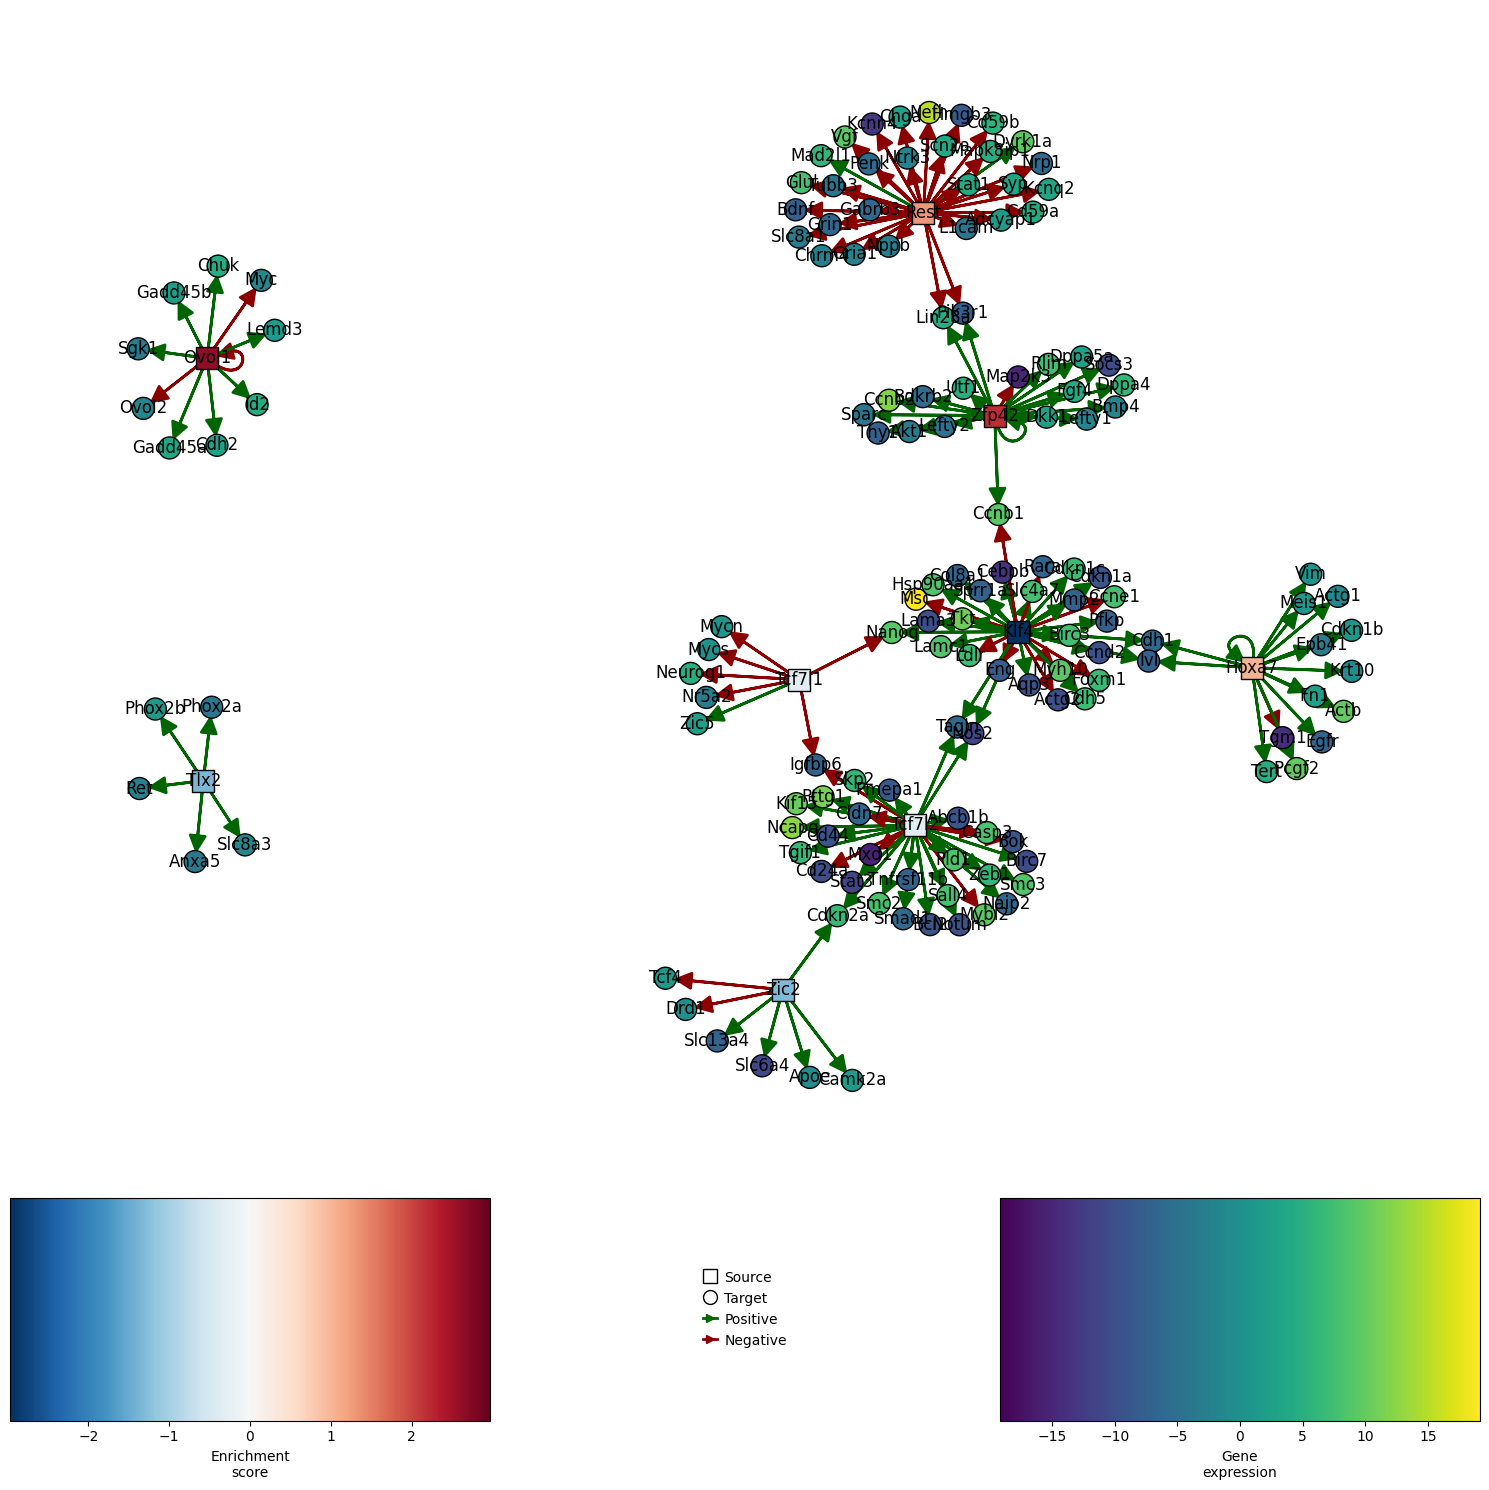

In [61]:
# Plot Ovol1 network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=drivers_with_activities + ["Hic2", "Klf4"],
    targets=30,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=50,
)